# Phase 7 — Full-Sequence Time-Reversal Classification

## Goal

Phase 6 analyzed ordered two-step trajectories using the reduced feature
representation

$$
(\Delta m,\sin\theta).
$$

That representation was interpretable but intentionally discarded part of
the information contained in the original ordered sequence.

Phase 7 asks whether time-direction information becomes detectable when the
full two-step displacement sequence is retained:

$$
S
=
(\Delta x_1,\Delta y_1,\Delta x_2,\Delta y_2).
$$

The correctly time-reversed sequence is

$$
R(S)
=
(-\Delta x_2,-\Delta y_2,-\Delta x_1,-\Delta y_1).
$$

Rather than estimating a probability density directly in four dimensions,
Phase 7 treats forward-versus-reversed discrimination as a supervised
classification problem.

Forward sequences are assigned one class label and their time-reversed
counterparts the other.

If the selected sequence representation contains detectable information
about temporal direction, a classifier may distinguish the two classes
better than expected under a time-reversal-symmetric null model.

The analysis remains exploratory and does not equate classification
performance with thermodynamic entropy production.

## Preventing information leakage

Multiple sequences come from the same biological cell and therefore cannot be
treated as statistically independent observations.

In addition, every observed forward sequence has a directly constructed
time-reversed counterpart.

A naive random train/test split could therefore leak highly related examples
between the training and test sets.

Phase 7 avoids this problem by performing cross-validation at the
**cell level**.

All forward and reversed sequences belonging to a given cell remain in the
same cross-validation fold.

Therefore, when a cell is used for testing, no sequence from that cell appears
in the training data.

This grouped design tests whether time-direction information generalizes
across cells rather than merely allowing a classifier to memorize individual
trajectory patterns.

In [1]:
%run _path.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.steps import (
    validate_tracks,
    compute_steps_for_tau,
)

FRAME_INTERVAL_MIN = 20
RANDOM_SEED = 2026
N_CV_SPLITS = 5

print("Phase 7 environment loaded.")
print("Project root:", PROJECT_ROOT)

Phase 7 environment loaded.
Project root: C:\Users\Abolfazl.PH\Desktop\cell-irreversibility


In [2]:
RAW_TRACKS_PATH = (
    PROJECT_ROOT
    / "data"
    / "MSC01_tracks_clean.csv"
)

COMOVING_TRACKS_PATH = (
    PROJECT_ROOT
    / "data"
    / "MSC01_tracks_comoving.csv"
)

TRACK_COLUMNS = [
    "cell_id",
    "frame",
    "t_min",
    "x_um",
    "y_um",
]

raw_tracks = (
    pd.read_csv(RAW_TRACKS_PATH)
    [TRACK_COLUMNS]
    .sort_values(
        ["cell_id", "frame"]
    )
    .reset_index(drop=True)
    .copy()
)

comoving_tracks = (
    pd.read_csv(COMOVING_TRACKS_PATH)
    [TRACK_COLUMNS]
    .sort_values(
        ["cell_id", "frame"]
    )
    .reset_index(drop=True)
    .copy()
)

validate_tracks(raw_tracks)
validate_tracks(comoving_tracks)

print(
    "Raw tracks:",
    raw_tracks.shape,
)

print(
    "Co-moving tracks:",
    comoving_tracks.shape,
)

Raw tracks: (474, 5)
Co-moving tracks: (474, 5)


In [3]:
def build_two_step_sequences(
    tracks: pd.DataFrame,
) -> pd.DataFrame:
    """
    Construct exact two-step sequences:

        t -> t+1 -> t+2

    using validated exact one-frame displacement steps.
    """

    validate_tracks(tracks)

    one_frame_steps = compute_steps_for_tau(
        tracks,
        tau_frames=1,
    )

    first_steps = (
        one_frame_steps
        .rename(
            columns={
                "frame_end": "frame_mid",
                "t_end_min": "t_mid_min",
                "dx_um": "dx1_um",
                "dy_um": "dy1_um",
            }
        )
        [
            [
                "cell_id",
                "frame_start",
                "t_start_min",
                "frame_mid",
                "t_mid_min",
                "dx1_um",
                "dy1_um",
            ]
        ]
        .copy()
    )

    second_steps = (
        one_frame_steps
        .rename(
            columns={
                "frame_start": "frame_mid",
                "dx_um": "dx2_um",
                "dy_um": "dy2_um",
            }
        )
        [
            [
                "cell_id",
                "frame_mid",
                "frame_end",
                "t_end_min",
                "dx2_um",
                "dy2_um",
            ]
        ]
        .copy()
    )

    sequences = first_steps.merge(
        second_steps,
        on=[
            "cell_id",
            "frame_mid",
        ],
        how="inner",
        validate="one_to_one",
    )

    valid_first_step = (
        sequences["frame_mid"]
        == sequences["frame_start"] + 1
    )

    valid_second_step = (
        sequences["frame_end"]
        == sequences["frame_mid"] + 1
    )

    if not (
        valid_first_step.all()
        and valid_second_step.all()
    ):
        raise RuntimeError(
            "Non-consecutive sequence detected."
        )

    return (
        sequences
        .sort_values(
            [
                "cell_id",
                "frame_start",
            ]
        )
        .reset_index(drop=True)
    )

In [4]:
raw_sequences = build_two_step_sequences(
    raw_tracks
)

comoving_sequences = build_two_step_sequences(
    comoving_tracks
)

STRUCTURE_COLUMNS = [
    "cell_id",
    "frame_start",
    "frame_mid",
    "frame_end",
]

pd.testing.assert_frame_equal(
    raw_sequences[
        STRUCTURE_COLUMNS
    ],
    comoving_sequences[
        STRUCTURE_COLUMNS
    ],
)

assert len(raw_sequences) == 392
assert len(comoving_sequences) == 392

print(
    "Raw sequences:",
    len(raw_sequences),
)

print(
    "Co-moving sequences:",
    len(comoving_sequences),
)

print(
    "Cells:",
    raw_sequences[
        "cell_id"
    ].nunique(),
)

print(
    "Sequence reconstruction: PASSED"
)


Raw sequences: 392
Co-moving sequences: 392
Cells: 32
Sequence reconstruction: PASSED


In [5]:
SEQUENCE_COLUMNS = [
    "dx1_um",
    "dy1_um",
    "dx2_um",
    "dy2_um",
]


def get_sequence_array(
    sequences: pd.DataFrame,
) -> np.ndarray:
    return (
        sequences[
            SEQUENCE_COLUMNS
        ]
        .to_numpy(dtype=float)
    )


def reverse_two_step_sequences(
    sequence_array: np.ndarray,
) -> np.ndarray:
    """
    Forward:
        [dx1, dy1, dx2, dy2]

    Reverse:
        [-dx2, -dy2, -dx1, -dy1]
    """

    sequence_array = np.asarray(
        sequence_array,
        dtype=float,
    )

    if (
        sequence_array.ndim != 2
        or sequence_array.shape[1] != 4
    ):
        raise ValueError(
            "Expected shape (n, 4)."
        )

    return np.column_stack(
        [
            -sequence_array[:, 2],
            -sequence_array[:, 3],
            -sequence_array[:, 0],
            -sequence_array[:, 1],
        ]
    )


raw_forward = get_sequence_array(
    raw_sequences
)

raw_reverse = (
    reverse_two_step_sequences(
        raw_forward
    )
)

comoving_forward = get_sequence_array(
    comoving_sequences
)

comoving_reverse = (
    reverse_two_step_sequences(
        comoving_forward
    )
)

assert np.allclose(
    reverse_two_step_sequences(
        raw_reverse
    ),
    raw_forward,
)

assert np.allclose(
    reverse_two_step_sequences(
        comoving_reverse
    ),
    comoving_forward,
)

print(
    "Raw sequence shape:",
    raw_forward.shape,
)

print(
    "Co-moving sequence shape:",
    comoving_forward.shape,
)

print(
    "Time-reversal validation: PASSED"
)

Raw sequence shape: (392, 4)
Co-moving sequence shape: (392, 4)
Time-reversal validation: PASSED


## Constructing the classification dataset

For each observed forward sequence,

$$
S_i,
$$

the analysis includes its correctly time-reversed counterpart,

$$
R(S_i).
$$

The two classes are defined as:

- **Forward sequence** → label `1`
- **Time-reversed sequence** → label `0`

Because every forward observation contributes exactly one reversed
counterpart, the classification dataset is perfectly class-balanced.

For 392 observed sequences, each representation therefore contains:

- 392 forward examples
- 392 reversed examples
- 784 total classifier examples

The biological cell identifier is duplicated for the forward and reversed
versions of each sequence and is used only as the grouping variable during
cross-validation.

This is important because sequences originating from the same biological
cell are statistically related. Keeping the cell identifier as a grouping
variable allows all examples from a given cell to remain together in either
the training or test portion of each cross-validation fold.

The cell identifier itself is **not** supplied to the classifier as a
predictive feature.

In [6]:
def build_classification_dataset(
    forward_array: np.ndarray,
    reverse_array: np.ndarray,
    cell_ids: np.ndarray,
):
    """
    Construct a balanced forward-versus-reversed
    classification dataset.
    """

    if forward_array.shape != reverse_array.shape:
        raise ValueError(
            "Forward and reverse arrays "
            "must have identical shapes."
        )

    if len(cell_ids) != len(forward_array):
        raise ValueError(
            "cell_ids length does not match "
            "the number of sequences."
        )

    X = np.vstack(
        [
            forward_array,
            reverse_array,
        ]
    )

    y = np.concatenate(
        [
            np.ones(
                len(forward_array),
                dtype=int,
            ),
            np.zeros(
                len(reverse_array),
                dtype=int,
            ),
        ]
    )

    groups = np.concatenate(
        [
            cell_ids,
            cell_ids,
        ]
    )

    return X, y, groups

In [7]:
cell_ids = (
    raw_sequences[
        "cell_id"
    ]
    .to_numpy()
)

(
    X_raw,
    y_raw,
    groups_raw,
) = build_classification_dataset(
    raw_forward,
    raw_reverse,
    cell_ids,
)

(
    X_comoving,
    y_comoving,
    groups_comoving,
) = build_classification_dataset(
    comoving_forward,
    comoving_reverse,
    cell_ids,
)

print(
    "Raw classifier X shape:",
    X_raw.shape,
)

print(
    "Raw labels shape:",
    y_raw.shape,
)

print(
    "Forward labels:",
    int(y_raw.sum()),
)

print(
    "Reverse labels:",
    int(
        len(y_raw)
        - y_raw.sum()
    ),
)

print(
    "Unique cell groups:",
    len(
        np.unique(groups_raw)
    ),
)

Raw classifier X shape: (784, 4)
Raw labels shape: (784,)
Forward labels: 392
Reverse labels: 392
Unique cell groups: 32


In [8]:
assert X_raw.shape == (
    784,
    4,
)

assert X_comoving.shape == (
    784,
    4,
)

assert y_raw.sum() == 392
assert y_comoving.sum() == 392

assert np.array_equal(
    y_raw,
    y_comoving,
)

assert np.array_equal(
    groups_raw,
    groups_comoving,
)

assert len(
    np.unique(groups_raw)
) == 32

print(
    "Classification dataset validation: PASSED"
)

Classification dataset validation: PASSED


In [9]:
group_cv = GroupKFold(
    n_splits=N_CV_SPLITS
)

cv_records = []

for fold_id, (
    train_index,
    test_index,
) in enumerate(
    group_cv.split(
        X_raw,
        y_raw,
        groups_raw,
    ),
    start=1,
):

    train_groups = np.unique(
        groups_raw[
            train_index
        ]
    )

    test_groups = np.unique(
        groups_raw[
            test_index
        ]
    )

    overlap = np.intersect1d(
        train_groups,
        test_groups,
    )

    assert len(overlap) == 0

    cv_records.append(
        {
            "fold": fold_id,
            "n_train_examples": len(
                train_index
            ),
            "n_test_examples": len(
                test_index
            ),
            "n_train_cells": len(
                train_groups
            ),
            "n_test_cells": len(
                test_groups
            ),
            "train_forward_fraction": (
                y_raw[
                    train_index
                ].mean()
            ),
            "test_forward_fraction": (
                y_raw[
                    test_index
                ].mean()
            ),
        }
    )

cv_summary = pd.DataFrame(
    cv_records
)

display(cv_summary)

print(
    "Cell-group leakage check: PASSED"
)

,fold,n_train_examples,n_test_examples,n_train_cells,n_test_cells,train_forward_fraction,test_forward_fraction
0,1,626,158,26,6,0.5,0.5
1,2,626,158,25,7,0.5,0.5
2,3,628,156,26,6,0.5,0.5
3,4,628,156,25,7,0.5,0.5
4,5,628,156,26,6,0.5,0.5


Cell-group leakage check: PASSED


## Baseline linear time-direction classifier

The first Phase 7 classifier is logistic regression.

The input features are the four components of the complete ordered
two-step sequence:

$$
X =
(\Delta x_1,\Delta y_1,\Delta x_2,\Delta y_2).
$$

The target is binary:

- forward sequence: `1`
- time-reversed sequence: `0`

Logistic regression estimates the probability that an input sequence belongs
to the forward class.

Conceptually, the model first forms a linear score,

$$
z =
\beta_0
+
\beta_1\Delta x_1
+
\beta_2\Delta y_1
+
\beta_3\Delta x_2
+
\beta_4\Delta y_2,
$$

and converts that score into a probability using the logistic function.

A model with no useful information about temporal direction should generalize
at approximately chance level.

Because displacement components may have different numerical scales,
standardization is performed inside each training fold using
`StandardScaler`.

The scaler and classifier are combined in a scikit-learn `Pipeline`.

Placing scaling inside the pipeline is essential: the scaler is fitted only
on the training cells of each fold and never sees the held-out test cells.
This prevents preprocessing leakage.

In [10]:
baseline_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
            ),
        ),
    ]
)

baseline_model

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


## Evaluation metrics

Two complementary metrics are used.

### ROC AUC

ROC AUC measures how well the classifier ranks forward sequences above
reversed sequences across possible decision thresholds.

Interpretation:

- `AUC = 0.5`: chance-level discrimination
- `AUC > 0.5`: some forward/reverse ranking information
- `AUC = 1.0`: perfect discrimination

An observed AUC above 0.5 is not sufficient by itself to establish a
time-direction signal. It must later be compared with an appropriate null
distribution.

### Balanced accuracy

Balanced accuracy averages sensitivity across the two classes.

Because the Phase 7 classification dataset is exactly class-balanced,
ordinary accuracy and balanced accuracy would be very similar here.

Balanced accuracy is retained because it makes the evaluation definition
explicit and remains appropriate if later sensitivity analyses alter the
class composition.

As with AUC, chance performance is approximately

$$
0.5.
$$

In [11]:
def evaluate_grouped_classifier(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    model,
    n_splits: int = 5,
) -> pd.DataFrame:
    """
    Evaluate a classifier using cell-grouped cross-validation.

    All examples from the same biological cell remain
    in the same fold.
    """

    cv = GroupKFold(
        n_splits=n_splits
    )

    records = []

    for fold_id, (
        train_index,
        test_index,
    ) in enumerate(
        cv.split(
            X,
            y,
            groups,
        ),
        start=1,
    ):

        model.fit(
            X[train_index],
            y[train_index],
        )

        forward_probability = (
            model.predict_proba(
                X[test_index]
            )[:, 1]
        )

        predicted_label = (
            model.predict(
                X[test_index]
            )
        )

        auc = roc_auc_score(
            y[test_index],
            forward_probability,
        )

        balanced_accuracy = (
            balanced_accuracy_score(
                y[test_index],
                predicted_label,
            )
        )

        train_cells = np.unique(
            groups[train_index]
        )

        test_cells = np.unique(
            groups[test_index]
        )

        assert len(
            np.intersect1d(
                train_cells,
                test_cells,
            )
        ) == 0

        records.append(
            {
                "fold": fold_id,
                "n_train_examples": len(
                    train_index
                ),
                "n_test_examples": len(
                    test_index
                ),
                "n_test_cells": len(
                    test_cells
                ),
                "roc_auc": auc,
                "balanced_accuracy": (
                    balanced_accuracy
                ),
            }
        )

    return pd.DataFrame(
        records
    )

In [12]:
raw_cv_results = (
    evaluate_grouped_classifier(
        X=X_raw,
        y=y_raw,
        groups=groups_raw,
        model=baseline_model,
        n_splits=N_CV_SPLITS,
    )
)

display(
    raw_cv_results
)

,fold,n_train_examples,n_test_examples,n_test_cells,roc_auc,balanced_accuracy
0,1,626,158,6,0.637478,0.613924
1,2,626,158,7,0.662554,0.772152
2,3,628,156,6,0.615220,0.576923
3,4,628,156,7,0.483892,0.500000
4,5,628,156,6,0.710634,0.608974


In [13]:
comoving_cv_results = (
    evaluate_grouped_classifier(
        X=X_comoving,
        y=y_comoving,
        groups=groups_comoving,
        model=baseline_model,
        n_splits=N_CV_SPLITS,
    )
)

display(
    comoving_cv_results
)

,fold,n_train_examples,n_test_examples,n_test_cells,roc_auc,balanced_accuracy
0,1,626,158,6,0.520429,0.556962
1,2,626,158,7,0.611601,0.645570
2,3,628,156,6,0.497041,0.461538
3,4,628,156,7,0.384944,0.410256
4,5,628,156,6,0.506739,0.525641


In [14]:
observed_performance = pd.DataFrame(
    [
        {
            "representation": "raw",
            "mean_roc_auc": (
                raw_cv_results[
                    "roc_auc"
                ].mean()
            ),
            "std_roc_auc": (
                raw_cv_results[
                    "roc_auc"
                ].std(ddof=1)
            ),
            "mean_balanced_accuracy": (
                raw_cv_results[
                    "balanced_accuracy"
                ].mean()
            ),
            "std_balanced_accuracy": (
                raw_cv_results[
                    "balanced_accuracy"
                ].std(ddof=1)
            ),
        },
        {
            "representation": "comoving",
            "mean_roc_auc": (
                comoving_cv_results[
                    "roc_auc"
                ].mean()
            ),
            "std_roc_auc": (
                comoving_cv_results[
                    "roc_auc"
                ].std(ddof=1)
            ),
            "mean_balanced_accuracy": (
                comoving_cv_results[
                    "balanced_accuracy"
                ].mean()
            ),
            "std_balanced_accuracy": (
                comoving_cv_results[
                    "balanced_accuracy"
                ].std(ddof=1)
            ),
        },
    ]
)

display(
    observed_performance
)

,representation,mean_roc_auc,std_roc_auc,mean_balanced_accuracy,std_balanced_accuracy
0,raw,0.621956,0.084941,0.614395,0.099256
1,comoving,0.504151,0.080743,0.519994,0.090315


In [15]:
for results in [
    raw_cv_results,
    comoving_cv_results,
]:

    assert len(results) == 5

    assert (
        results[
            "roc_auc"
        ]
        .between(
            0.0,
            1.0,
        )
        .all()
    )

    assert (
        results[
            "balanced_accuracy"
        ]
        .between(
            0.0,
            1.0,
        )
        .all()
    )

assert np.isfinite(
    observed_performance[
        [
            "mean_roc_auc",
            "std_roc_auc",
            "mean_balanced_accuracy",
            "std_balanced_accuracy",
        ]
    ].to_numpy()
).all()

print(
    "Baseline classifier validation: PASSED"
)

Baseline classifier validation: PASSED


## Time-reversal-symmetrized classification null

The observed classifier performance must be compared with a null model that
preserves the paired structure of the Phase 7 dataset.

A simple independent shuffle of all class labels would destroy the exact
relationship between each observed sequence and its time-reversed
counterpart.

Instead, the null model operates at the sequence-pair level.

For every pair

$$
\{S_i,R(S_i)\},
$$

a random binary choice determines which orientation is treated as the
pseudo-forward example.

With probability one half,

$$
S_i \rightarrow 1,
\qquad
R(S_i) \rightarrow 0,
$$

and otherwise,

$$
R(S_i) \rightarrow 1,
\qquad
S_i \rightarrow 0.
$$

This randomizes the temporal orientation while preserving:

- the observed sequence values;
- the exact forward/reverse pair structure;
- cell membership;
- class balance;
- sample size;
- and the grouped cross-validation design.

The same random orientation choices are applied to the raw and co-moving
representations during each null replicate so that their comparison remains
paired.

Observed classifier performance will then be compared with the distribution
of performance obtained under this time-direction-symmetrized null.

In [16]:
def randomize_pair_orientation(
    forward_array: np.ndarray,
    reverse_array: np.ndarray,
    swap_mask: np.ndarray,
):
    """
    Randomly exchange the forward and reversed member
    of selected sequence pairs.

    Parameters
    ----------
    forward_array
        Observed forward sequences.

    reverse_array
        Correctly time-reversed sequences.

    swap_mask
        Boolean array of length n_sequences.
        True means that the pair orientation is swapped.
    """

    if forward_array.shape != reverse_array.shape:
        raise ValueError(
            "Forward and reverse arrays must have identical shapes."
        )

    if len(swap_mask) != len(forward_array):
        raise ValueError(
            "swap_mask length must equal the number of sequence pairs."
        )

    pseudo_forward = forward_array.copy()
    pseudo_reverse = reverse_array.copy()

    pseudo_forward[swap_mask] = (
        reverse_array[swap_mask]
    )

    pseudo_reverse[swap_mask] = (
        forward_array[swap_mask]
    )

    return pseudo_forward, pseudo_reverse

In [17]:
test_rng = np.random.default_rng(
    RANDOM_SEED
)

test_swap_mask = test_rng.random(
    len(raw_forward)
) < 0.5

(
    test_raw_pseudo_forward,
    test_raw_pseudo_reverse,
) = randomize_pair_orientation(
    raw_forward,
    raw_reverse,
    test_swap_mask,
)

assert (
    test_raw_pseudo_forward.shape
    == raw_forward.shape
)

assert (
    test_raw_pseudo_reverse.shape
    == raw_reverse.shape
)

for i in range(len(raw_forward)):

    if test_swap_mask[i]:

        assert np.allclose(
            test_raw_pseudo_forward[i],
            raw_reverse[i],
        )

        assert np.allclose(
            test_raw_pseudo_reverse[i],
            raw_forward[i],
        )

    else:

        assert np.allclose(
            test_raw_pseudo_forward[i],
            raw_forward[i],
        )

        assert np.allclose(
            test_raw_pseudo_reverse[i],
            raw_reverse[i],
        )

print(
    "Pair-orientation null transformation: PASSED"
)

print(
    "Swapped pairs:",
    int(test_swap_mask.sum()),
    "/",
    len(test_swap_mask),
)

Pair-orientation null transformation: PASSED
Swapped pairs: 195 / 392


In [18]:
N_NULL_REPLICATES = 200

null_rng = np.random.default_rng(
    RANDOM_SEED + 1
)

null_records = []

for null_id in range(
    1,
    N_NULL_REPLICATES + 1,
):

    swap_mask = (
        null_rng.random(
            len(raw_forward)
        )
        < 0.5
    )

    (
        raw_null_forward,
        raw_null_reverse,
    ) = randomize_pair_orientation(
        raw_forward,
        raw_reverse,
        swap_mask,
    )

    (
        comoving_null_forward,
        comoving_null_reverse,
    ) = randomize_pair_orientation(
        comoving_forward,
        comoving_reverse,
        swap_mask,
    )

    (
        X_raw_null,
        y_raw_null,
        groups_raw_null,
    ) = build_classification_dataset(
        raw_null_forward,
        raw_null_reverse,
        cell_ids,
    )

    (
        X_comoving_null,
        y_comoving_null,
        groups_comoving_null,
    ) = build_classification_dataset(
        comoving_null_forward,
        comoving_null_reverse,
        cell_ids,
    )

    raw_null_cv = (
        evaluate_grouped_classifier(
            X=X_raw_null,
            y=y_raw_null,
            groups=groups_raw_null,
            model=baseline_model,
            n_splits=N_CV_SPLITS,
        )
    )

    comoving_null_cv = (
        evaluate_grouped_classifier(
            X=X_comoving_null,
            y=y_comoving_null,
            groups=groups_comoving_null,
            model=baseline_model,
            n_splits=N_CV_SPLITS,
        )
    )

    raw_auc = (
        raw_null_cv[
            "roc_auc"
        ].mean()
    )

    comoving_auc = (
        comoving_null_cv[
            "roc_auc"
        ].mean()
    )

    raw_balanced_accuracy = (
        raw_null_cv[
            "balanced_accuracy"
        ].mean()
    )

    comoving_balanced_accuracy = (
        comoving_null_cv[
            "balanced_accuracy"
        ].mean()
    )

    null_records.append(
        {
            "null_id": null_id,
            "raw_roc_auc": raw_auc,
            "comoving_roc_auc": comoving_auc,
            "raw_balanced_accuracy": (
                raw_balanced_accuracy
            ),
            "comoving_balanced_accuracy": (
                comoving_balanced_accuracy
            ),
            "raw_minus_comoving_auc": (
                raw_auc - comoving_auc
            ),
        }
    )

null_results = pd.DataFrame(
    null_records
)

display(
    null_results.head()
)

print(
    "Null replicates:",
    len(null_results)
)

,null_id,raw_roc_auc,comoving_roc_auc,raw_balanced_accuracy,comoving_balanced_accuracy,raw_minus_comoving_auc
0,1,0.507341,0.499706,0.512577,0.512561,0.007635
1,2,0.435462,0.431514,0.464541,0.459429,0.003949
2,3,0.518843,0.530928,0.497257,0.505063,-0.012085
3,4,0.458624,0.476263,0.489890,0.466861,-0.017639
4,5,0.469726,0.480882,0.510240,0.494937,-0.011156


Null replicates: 200


In [19]:
observed_raw_auc = (
    raw_cv_results[
        "roc_auc"
    ].mean()
)

observed_comoving_auc = (
    comoving_cv_results[
        "roc_auc"
    ].mean()
)

observed_auc_difference = (
    observed_raw_auc
    - observed_comoving_auc
)


def empirical_upper_pvalue(
    observed: float,
    null_values: np.ndarray,
) -> float:
    """
    One-sided empirical p-value with a +1 correction.
    """

    null_values = np.asarray(
        null_values,
        dtype=float,
    )

    return (
        1
        + np.sum(
            null_values >= observed
        )
    ) / (
        len(null_values) + 1
    )


null_summary = pd.DataFrame(
    [
        {
            "metric": "raw_roc_auc",
            "observed": observed_raw_auc,
            "null_mean": null_results[
                "raw_roc_auc"
            ].mean(),
            "null_q95": null_results[
                "raw_roc_auc"
            ].quantile(0.95),
            "empirical_p": empirical_upper_pvalue(
                observed_raw_auc,
                null_results[
                    "raw_roc_auc"
                ].to_numpy(),
            ),
        },
        {
            "metric": "comoving_roc_auc",
            "observed": (
                observed_comoving_auc
            ),
            "null_mean": null_results[
                "comoving_roc_auc"
            ].mean(),
            "null_q95": null_results[
                "comoving_roc_auc"
            ].quantile(0.95),
            "empirical_p": empirical_upper_pvalue(
                observed_comoving_auc,
                null_results[
                    "comoving_roc_auc"
                ].to_numpy(),
            ),
        },
        {
            "metric": "raw_minus_comoving_auc",
            "observed": (
                observed_auc_difference
            ),
            "null_mean": null_results[
                "raw_minus_comoving_auc"
            ].mean(),
            "null_q95": null_results[
                "raw_minus_comoving_auc"
            ].quantile(0.95),
            "empirical_p": empirical_upper_pvalue(
                observed_auc_difference,
                null_results[
                    "raw_minus_comoving_auc"
                ].to_numpy(),
            ),
        },
    ]
)

null_summary[
    "above_null_q95"
] = (
    null_summary["observed"]
    >
    null_summary["null_q95"]
)

display(
    null_summary
)

,metric,observed,null_mean,null_q95,empirical_p,above_null_q95
0,raw_roc_auc,0.621956,0.500347,0.555552,0.004975,True
1,comoving_roc_auc,0.504151,0.502024,0.559142,0.512438,False
2,raw_minus_comoving_auc,0.117805,-0.001677,0.033821,0.004975,True


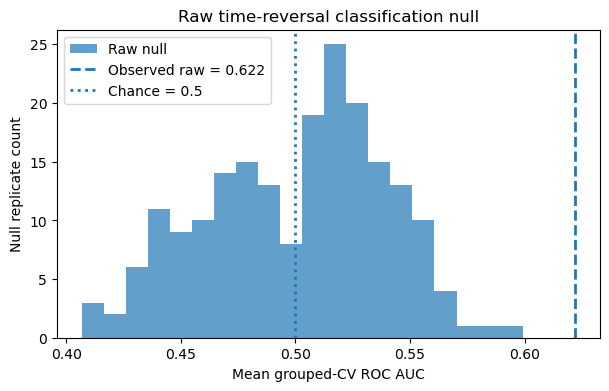

In [20]:
plt.figure(
    figsize=(7, 4)
)

plt.hist(
    null_results[
        "raw_roc_auc"
    ],
    bins=20,
    alpha=0.7,
    label="Raw null",
)

plt.axvline(
    observed_raw_auc,
    linestyle="--",
    linewidth=2,
    label=(
        f"Observed raw = "
        f"{observed_raw_auc:.3f}"
    ),
)

plt.axvline(
    0.5,
    linestyle=":",
    linewidth=2,
    label="Chance = 0.5",
)

plt.xlabel(
    "Mean grouped-CV ROC AUC"
)

plt.ylabel(
    "Null replicate count"
)

plt.title(
    "Raw time-reversal classification null"
)

plt.legend()

plt.show()

In [21]:
assert len(
    null_results
) == N_NULL_REPLICATES

assert np.isfinite(
    null_results.to_numpy()
).all()

for column in [
    "raw_roc_auc",
    "comoving_roc_auc",
    "raw_balanced_accuracy",
    "comoving_balanced_accuracy",
]:

    assert (
        null_results[column]
        .between(
            0.0,
            1.0,
        )
        .all()
    )

assert (
    null_summary[
        "empirical_p"
    ]
    .between(
        0.0,
        1.0,
    )
    .all()
)

print(
    "Time-reversal null validation: PASSED"
)

Time-reversal null validation: PASSED


## Decomposing the full sequence into reversal-odd and reversal-even coordinates

The baseline logistic-regression classifier produced forward-versus-reversed
performance above the time-reversal-symmetrized null for the raw
representation, whereas the co-moving representation remained near chance.

Before interpreting this as evidence of sequence-order information, the
structure of the linear classifier must be examined more carefully.

For a two-step sequence,

$$
S=(\mathbf{d}_1,\mathbf{d}_2),
$$

define the reversal-odd coordinate

$$
\mathbf{o}
=
\mathbf{d}_1+\mathbf{d}_2
$$

and the reversal-even coordinate

$$
\mathbf{e}
=
\mathbf{d}_1-\mathbf{d}_2.
$$

Under the Phase 7 time-reversal transformation,

$$
R(S)=(-\mathbf{d}_2,-\mathbf{d}_1),
$$

these coordinates transform as

$$
\mathbf{o}\rightarrow-\mathbf{o}
$$

and

$$
\mathbf{e}\rightarrow\mathbf{e}.
$$

The odd coordinate also has a simple physical meaning:

$$
\mathbf{d}_1+\mathbf{d}_2
=
\mathbf{r}_{t+2}-\mathbf{r}_t.
$$

It is therefore the net displacement across the complete two-step interval.

A linear classifier can exploit this reversal-odd net-displacement signal
without necessarily using more complex information about temporal ordering.

The following analysis separates the odd and even subspaces to determine
which part of the sequence carries the observed linear classification signal.

In [22]:
def decompose_reversal_coordinates(
    sequence_array: np.ndarray,
):
    """
    Decompose a two-step sequence into
    reversal-odd and reversal-even coordinates.

    Input columns:
        [dx1, dy1, dx2, dy2]

    Returns
    -------
    odd
        [dx1 + dx2, dy1 + dy2]

    even
        [dx1 - dx2, dy1 - dy2]
    """

    sequence_array = np.asarray(
        sequence_array,
        dtype=float,
    )

    if (
        sequence_array.ndim != 2
        or sequence_array.shape[1] != 4
    ):
        raise ValueError(
            "Expected sequence array with shape (n, 4)."
        )

    first_step = sequence_array[:, 0:2]
    second_step = sequence_array[:, 2:4]

    odd = (
        first_step
        + second_step
    )

    even = (
        first_step
        - second_step
    )

    return odd, even

In [23]:
(
    raw_odd_forward,
    raw_even_forward,
) = decompose_reversal_coordinates(
    raw_forward
)

(
    raw_odd_reverse,
    raw_even_reverse,
) = decompose_reversal_coordinates(
    raw_reverse
)

(
    comoving_odd_forward,
    comoving_even_forward,
) = decompose_reversal_coordinates(
    comoving_forward
)

(
    comoving_odd_reverse,
    comoving_even_reverse,
) = decompose_reversal_coordinates(
    comoving_reverse
)


assert np.allclose(
    raw_odd_reverse,
    -raw_odd_forward,
)

assert np.allclose(
    raw_even_reverse,
    raw_even_forward,
)

assert np.allclose(
    comoving_odd_reverse,
    -comoving_odd_forward,
)

assert np.allclose(
    comoving_even_reverse,
    comoving_even_forward,
)

print(
    "Reversal-coordinate transformation: PASSED"
)

print(
    "Odd coordinate shape:",
    raw_odd_forward.shape,
)

print(
    "Even coordinate shape:",
    raw_even_forward.shape,
)

Reversal-coordinate transformation: PASSED
Odd coordinate shape: (392, 2)
Even coordinate shape: (392, 2)


In [24]:
(
    X_raw_odd,
    y_raw_odd,
    groups_raw_odd,
) = build_classification_dataset(
    raw_odd_forward,
    raw_odd_reverse,
    cell_ids,
)

(
    X_raw_even,
    y_raw_even,
    groups_raw_even,
) = build_classification_dataset(
    raw_even_forward,
    raw_even_reverse,
    cell_ids,
)

(
    X_comoving_odd,
    y_comoving_odd,
    groups_comoving_odd,
) = build_classification_dataset(
    comoving_odd_forward,
    comoving_odd_reverse,
    cell_ids,
)

(
    X_comoving_even,
    y_comoving_even,
    groups_comoving_even,
) = build_classification_dataset(
    comoving_even_forward,
    comoving_even_reverse,
    cell_ids,
)

print(
    "Raw odd X:",
    X_raw_odd.shape
)

print(
    "Raw even X:",
    X_raw_even.shape
)

print(
    "Co-moving odd X:",
    X_comoving_odd.shape
)

print(
    "Co-moving even X:",
    X_comoving_even.shape
)

Raw odd X: (784, 2)
Raw even X: (784, 2)
Co-moving odd X: (784, 2)
Co-moving even X: (784, 2)


In [25]:
raw_odd_cv = evaluate_grouped_classifier(
    X=X_raw_odd,
    y=y_raw_odd,
    groups=groups_raw_odd,
    model=baseline_model,
    n_splits=N_CV_SPLITS,
)

raw_even_cv = evaluate_grouped_classifier(
    X=X_raw_even,
    y=y_raw_even,
    groups=groups_raw_even,
    model=baseline_model,
    n_splits=N_CV_SPLITS,
)

comoving_odd_cv = evaluate_grouped_classifier(
    X=X_comoving_odd,
    y=y_comoving_odd,
    groups=groups_comoving_odd,
    model=baseline_model,
    n_splits=N_CV_SPLITS,
)

comoving_even_cv = evaluate_grouped_classifier(
    X=X_comoving_even,
    y=y_comoving_even,
    groups=groups_comoving_even,
    model=baseline_model,
    n_splits=N_CV_SPLITS,
)

In [26]:
subspace_summary = pd.DataFrame(
    [
        {
            "representation": "raw",
            "feature_space": "full_4D",
            "mean_roc_auc": raw_cv_results[
                "roc_auc"
            ].mean(),
            "mean_balanced_accuracy": raw_cv_results[
                "balanced_accuracy"
            ].mean(),
        },
        {
            "representation": "raw",
            "feature_space": "odd_net_displacement",
            "mean_roc_auc": raw_odd_cv[
                "roc_auc"
            ].mean(),
            "mean_balanced_accuracy": raw_odd_cv[
                "balanced_accuracy"
            ].mean(),
        },
        {
            "representation": "raw",
            "feature_space": "even_step_difference",
            "mean_roc_auc": raw_even_cv[
                "roc_auc"
            ].mean(),
            "mean_balanced_accuracy": raw_even_cv[
                "balanced_accuracy"
            ].mean(),
        },
        {
            "representation": "comoving",
            "feature_space": "full_4D",
            "mean_roc_auc": comoving_cv_results[
                "roc_auc"
            ].mean(),
            "mean_balanced_accuracy": comoving_cv_results[
                "balanced_accuracy"
            ].mean(),
        },
        {
            "representation": "comoving",
            "feature_space": "odd_net_displacement",
            "mean_roc_auc": comoving_odd_cv[
                "roc_auc"
            ].mean(),
            "mean_balanced_accuracy": comoving_odd_cv[
                "balanced_accuracy"
            ].mean(),
        },
        {
            "representation": "comoving",
            "feature_space": "even_step_difference",
            "mean_roc_auc": comoving_even_cv[
                "roc_auc"
            ].mean(),
            "mean_balanced_accuracy": comoving_even_cv[
                "balanced_accuracy"
            ].mean(),
        },
    ]
)

display(
    subspace_summary
)

,representation,feature_space,mean_roc_auc,mean_balanced_accuracy
0,raw,full_4D,0.621956,0.614395
1,raw,odd_net_displacement,0.621925,0.614395
2,raw,even_step_difference,0.500000,0.500000
3,comoving,full_4D,0.504151,0.519994
4,comoving,odd_net_displacement,0.504087,0.519994
5,comoving,even_step_difference,0.500000,0.500000


In [27]:
assert np.allclose(
    X_raw_even[:392],
    X_raw_even[392:],
)

assert np.allclose(
    X_comoving_even[:392],
    X_comoving_even[392:],
)

assert np.isfinite(
    subspace_summary[
        [
            "mean_roc_auc",
            "mean_balanced_accuracy",
        ]
    ].to_numpy()
).all()

print(
    "Reversal-subspace diagnostic: PASSED"
)

Reversal-subspace diagnostic: PASSED


## Nonlinear sensitivity analysis

The linear diagnostic showed that essentially all baseline logistic-regression
performance could be reproduced using only the reversal-odd net-displacement
coordinate.

For the raw representation,

$$
\mathrm{AUC}_{\mathrm{full}}
\approx
\mathrm{AUC}_{\mathrm{odd}},
$$

while the reversal-even subspace produced exactly chance-level
classification.

This indicates that the observed linear raw signal is primarily associated
with net directional displacement rather than with more complex two-step
ordering.

However, linear classification cannot detect general nonlinear interactions
between reversal-odd and reversal-even sequence coordinates.

For example, if

$$
o_x \rightarrow -o_x
$$

under time reversal while

$$
e_x \rightarrow e_x,
$$

then the interaction

$$
o_x e_x
$$

also changes sign under time reversal.

A nonlinear classifier can potentially detect such interactions without
explicitly constructing them as hand-designed features.

Phase 7 therefore includes one pre-specified nonlinear sensitivity model:
an RBF-kernel support vector classifier.

The purpose is not to search over many machine-learning models or optimize
performance aggressively.

Instead, the analysis asks whether retaining the complete four-dimensional
sequence reveals nonlinear forward-versus-reversed information that is not
already captured by net displacement alone.

The primary nonlinear comparisons are:

- raw full sequence versus raw odd-only coordinates;
- co-moving full sequence versus co-moving odd-only coordinates.

All evaluation remains cell-grouped and will be compared with the same
pair-orientation time-reversal null framework.

In [28]:
from sklearn.svm import SVC


rbf_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "classifier",
            SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
            ),
        ),
    ]
)

rbf_model

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [29]:
def evaluate_grouped_classifier_score(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    model,
    n_splits: int = 5,
) -> pd.DataFrame:
    """
    Evaluate a classifier with cell-grouped cross-validation.

    ROC AUC is computed from either decision_function()
    or predict_proba(), depending on model support.
    """

    cv = GroupKFold(
        n_splits=n_splits
    )

    records = []

    for fold_id, (
        train_index,
        test_index,
    ) in enumerate(
        cv.split(
            X,
            y,
            groups,
        ),
        start=1,
    ):

        model.fit(
            X[train_index],
            y[train_index],
        )

        if hasattr(
            model,
            "decision_function",
        ):
            forward_score = (
                model.decision_function(
                    X[test_index]
                )
            )

        else:
            forward_score = (
                model.predict_proba(
                    X[test_index]
                )[:, 1]
            )

        predicted_label = (
            model.predict(
                X[test_index]
            )
        )

        auc = roc_auc_score(
            y[test_index],
            forward_score,
        )

        balanced_accuracy = (
            balanced_accuracy_score(
                y[test_index],
                predicted_label,
            )
        )

        train_cells = np.unique(
            groups[train_index]
        )

        test_cells = np.unique(
            groups[test_index]
        )

        assert len(
            np.intersect1d(
                train_cells,
                test_cells,
            )
        ) == 0

        records.append(
            {
                "fold": fold_id,
                "n_test_cells": len(
                    test_cells
                ),
                "roc_auc": auc,
                "balanced_accuracy": (
                    balanced_accuracy
                ),
            }
        )

    return pd.DataFrame(
        records
    )

In [30]:
raw_full_rbf_cv = (
    evaluate_grouped_classifier_score(
        X=X_raw,
        y=y_raw,
        groups=groups_raw,
        model=rbf_model,
        n_splits=N_CV_SPLITS,
    )
)

raw_odd_rbf_cv = (
    evaluate_grouped_classifier_score(
        X=X_raw_odd,
        y=y_raw_odd,
        groups=groups_raw_odd,
        model=rbf_model,
        n_splits=N_CV_SPLITS,
    )
)

comoving_full_rbf_cv = (
    evaluate_grouped_classifier_score(
        X=X_comoving,
        y=y_comoving,
        groups=groups_comoving,
        model=rbf_model,
        n_splits=N_CV_SPLITS,
    )
)

comoving_odd_rbf_cv = (
    evaluate_grouped_classifier_score(
        X=X_comoving_odd,
        y=y_comoving_odd,
        groups=groups_comoving_odd,
        model=rbf_model,
        n_splits=N_CV_SPLITS,
    )
)


rbf_observed_summary = pd.DataFrame(
    [
        {
            "representation": "raw",
            "feature_space": "full_4D",
            "mean_roc_auc": (
                raw_full_rbf_cv[
                    "roc_auc"
                ].mean()
            ),
            "mean_balanced_accuracy": (
                raw_full_rbf_cv[
                    "balanced_accuracy"
                ].mean()
            ),
        },
        {
            "representation": "raw",
            "feature_space": "odd_net_displacement",
            "mean_roc_auc": (
                raw_odd_rbf_cv[
                    "roc_auc"
                ].mean()
            ),
            "mean_balanced_accuracy": (
                raw_odd_rbf_cv[
                    "balanced_accuracy"
                ].mean()
            ),
        },
        {
            "representation": "comoving",
            "feature_space": "full_4D",
            "mean_roc_auc": (
                comoving_full_rbf_cv[
                    "roc_auc"
                ].mean()
            ),
            "mean_balanced_accuracy": (
                comoving_full_rbf_cv[
                    "balanced_accuracy"
                ].mean()
            ),
        },
        {
            "representation": "comoving",
            "feature_space": "odd_net_displacement",
            "mean_roc_auc": (
                comoving_odd_rbf_cv[
                    "roc_auc"
                ].mean()
            ),
            "mean_balanced_accuracy": (
                comoving_odd_rbf_cv[
                    "balanced_accuracy"
                ].mean()
            ),
        },
    ]
)

display(
    rbf_observed_summary
)

,representation,feature_space,mean_roc_auc,mean_balanced_accuracy
0,raw,full_4D,0.557226,0.525625
1,raw,odd_net_displacement,0.565286,0.541042
2,comoving,full_4D,0.348291,0.372704
3,comoving,odd_net_displacement,0.371427,0.402077


In [31]:
rbf_fold_summary = pd.concat(
    [
        raw_full_rbf_cv.assign(
            representation="raw",
            feature_space="full_4D",
        ),
        raw_odd_rbf_cv.assign(
            representation="raw",
            feature_space="odd_net_displacement",
        ),
        comoving_full_rbf_cv.assign(
            representation="comoving",
            feature_space="full_4D",
        ),
        comoving_odd_rbf_cv.assign(
            representation="comoving",
            feature_space="odd_net_displacement",
        ),
    ],
    ignore_index=True,
)

rbf_fold_summary = rbf_fold_summary[
    [
        "representation",
        "feature_space",
        "fold",
        "n_test_cells",
        "roc_auc",
        "balanced_accuracy",
    ]
]

display(
    rbf_fold_summary
)

,representation,feature_space,fold,n_test_cells,roc_auc,balanced_accuracy
0,raw,full_4D,1,6,0.701410,0.651899
1,raw,full_4D,2,7,0.414357,0.354430
2,raw,full_4D,3,6,0.599934,0.589744
3,raw,full_4D,4,7,0.487179,0.512821
4,raw,full_4D,5,6,0.583251,0.519231
5,raw,odd_net_displacement,1,6,0.686188,0.639241
6,raw,odd_net_displacement,2,7,0.402980,0.354430
7,raw,odd_net_displacement,3,6,0.631986,0.602564
8,raw,odd_net_displacement,4,7,0.504602,0.551282
9,raw,odd_net_displacement,5,6,0.600674,0.557692


In [32]:
rbf_observed_summary = (
    rbf_observed_summary
    .copy()
)

rbf_observed_summary[
    "auc_minus_chance"
] = (
    rbf_observed_summary[
        "mean_roc_auc"
    ]
    - 0.5
)

rbf_observed_summary[
    "absolute_auc_deviation"
] = (
    rbf_observed_summary[
        "auc_minus_chance"
    ]
    .abs()
)

display(
    rbf_observed_summary
)

,representation,feature_space,mean_roc_auc,mean_balanced_accuracy,auc_minus_chance,absolute_auc_deviation
0,raw,full_4D,0.557226,0.525625,0.057226,0.057226
1,raw,odd_net_displacement,0.565286,0.541042,0.065286,0.065286
2,comoving,full_4D,0.348291,0.372704,-0.151709,0.151709
3,comoving,odd_net_displacement,0.371427,0.402077,-0.128573,0.128573


## Null validation of the nonlinear classifier

The observed RBF results must be evaluated against the same paired
time-reversal null used for the linear classifier.

For every null replicate, the temporal orientation of each exact
forward/reverse sequence pair is randomized.

The same pair-level swaps are applied to the raw and co-moving
representations.

Four pre-specified RBF analyses are evaluated:

- raw full 4D sequence;
- raw reversal-odd net displacement;
- co-moving full 4D sequence;
- co-moving reversal-odd net displacement.

Two questions are primary.

First, does the classifier achieve forward-direction discrimination above
the upper tail of the time-reversal-symmetrized null?

Second, does retaining the full four-dimensional sequence improve
classification relative to the odd net-displacement representation?

The quantity

$$
\Delta_{\mathrm{full-odd}}
=
\mathrm{AUC}_{\mathrm{full}}
-
\mathrm{AUC}_{\mathrm{odd}}
$$

is therefore also evaluated under the null.

AUC values below 0.5 are retained with their original sign and are not
post-hoc inverted.

Their distance from 0.5 may be described as a secondary diagnostic, but
below-chance performance is not interpreted as successful forward-time
classification.

In [33]:
N_RBF_NULL_REPLICATES = 200

rbf_null_rng = np.random.default_rng(
    RANDOM_SEED + 2
)

rbf_null_records = []

for null_id in range(
    1,
    N_RBF_NULL_REPLICATES + 1,
):

    swap_mask = (
        rbf_null_rng.random(
            len(raw_forward)
        )
        < 0.5
    )

    (
        raw_null_forward,
        raw_null_reverse,
    ) = randomize_pair_orientation(
        raw_forward,
        raw_reverse,
        swap_mask,
    )

    (
        comoving_null_forward,
        comoving_null_reverse,
    ) = randomize_pair_orientation(
        comoving_forward,
        comoving_reverse,
        swap_mask,
    )

    # Full 4D null datasets
    (
        X_raw_full_null,
        y_raw_full_null,
        groups_raw_full_null,
    ) = build_classification_dataset(
        raw_null_forward,
        raw_null_reverse,
        cell_ids,
    )

    (
        X_comoving_full_null,
        y_comoving_full_null,
        groups_comoving_full_null,
    ) = build_classification_dataset(
        comoving_null_forward,
        comoving_null_reverse,
        cell_ids,
    )

    # Reversal-odd coordinates
    (
        raw_null_odd_forward,
        _,
    ) = decompose_reversal_coordinates(
        raw_null_forward
    )

    (
        raw_null_odd_reverse,
        _,
    ) = decompose_reversal_coordinates(
        raw_null_reverse
    )

    (
        comoving_null_odd_forward,
        _,
    ) = decompose_reversal_coordinates(
        comoving_null_forward
    )

    (
        comoving_null_odd_reverse,
        _,
    ) = decompose_reversal_coordinates(
        comoving_null_reverse
    )

    (
        X_raw_odd_null,
        y_raw_odd_null,
        groups_raw_odd_null,
    ) = build_classification_dataset(
        raw_null_odd_forward,
        raw_null_odd_reverse,
        cell_ids,
    )

    (
        X_comoving_odd_null,
        y_comoving_odd_null,
        groups_comoving_odd_null,
    ) = build_classification_dataset(
        comoving_null_odd_forward,
        comoving_null_odd_reverse,
        cell_ids,
    )

    # Grouped RBF evaluation
    raw_full_null_cv = (
        evaluate_grouped_classifier_score(
            X=X_raw_full_null,
            y=y_raw_full_null,
            groups=groups_raw_full_null,
            model=rbf_model,
            n_splits=N_CV_SPLITS,
        )
    )

    raw_odd_null_cv = (
        evaluate_grouped_classifier_score(
            X=X_raw_odd_null,
            y=y_raw_odd_null,
            groups=groups_raw_odd_null,
            model=rbf_model,
            n_splits=N_CV_SPLITS,
        )
    )

    comoving_full_null_cv = (
        evaluate_grouped_classifier_score(
            X=X_comoving_full_null,
            y=y_comoving_full_null,
            groups=groups_comoving_full_null,
            model=rbf_model,
            n_splits=N_CV_SPLITS,
        )
    )

    comoving_odd_null_cv = (
        evaluate_grouped_classifier_score(
            X=X_comoving_odd_null,
            y=y_comoving_odd_null,
            groups=groups_comoving_odd_null,
            model=rbf_model,
            n_splits=N_CV_SPLITS,
        )
    )

    raw_full_auc = (
        raw_full_null_cv["roc_auc"].mean()
    )

    raw_odd_auc = (
        raw_odd_null_cv["roc_auc"].mean()
    )

    comoving_full_auc = (
        comoving_full_null_cv["roc_auc"].mean()
    )

    comoving_odd_auc = (
        comoving_odd_null_cv["roc_auc"].mean()
    )

    rbf_null_records.append(
        {
            "null_id": null_id,
            "raw_full_auc": raw_full_auc,
            "raw_odd_auc": raw_odd_auc,
            "raw_full_minus_odd": (
                raw_full_auc
                - raw_odd_auc
            ),
            "comoving_full_auc": (
                comoving_full_auc
            ),
            "comoving_odd_auc": (
                comoving_odd_auc
            ),
            "comoving_full_minus_odd": (
                comoving_full_auc
                - comoving_odd_auc
            ),
        }
    )

rbf_null_results = pd.DataFrame(
    rbf_null_records
)

display(
    rbf_null_results.head()
)

print(
    "RBF null replicates:",
    len(rbf_null_results)
)

,null_id,raw_full_auc,raw_odd_auc,raw_full_minus_odd,comoving_full_auc,comoving_odd_auc,comoving_full_minus_odd
0,1,0.525571,0.522749,0.002823,0.550942,0.563238,-0.012296
1,2,0.503799,0.427158,0.076641,0.494565,0.489028,0.005537
2,3,0.370651,0.457233,-0.086582,0.360595,0.462473,-0.101877
3,4,0.581226,0.569594,0.011632,0.556469,0.560330,-0.003861
4,5,0.508200,0.469738,0.038462,0.480137,0.493150,-0.013013


RBF null replicates: 200


In [34]:
observed_raw_full_rbf = (
    raw_full_rbf_cv[
        "roc_auc"
    ].mean()
)

observed_raw_odd_rbf = (
    raw_odd_rbf_cv[
        "roc_auc"
    ].mean()
)

observed_comoving_full_rbf = (
    comoving_full_rbf_cv[
        "roc_auc"
    ].mean()
)

observed_comoving_odd_rbf = (
    comoving_odd_rbf_cv[
        "roc_auc"
    ].mean()
)


rbf_null_summary = pd.DataFrame(
    [
        {
            "metric": "raw_full_auc",
            "observed": (
                observed_raw_full_rbf
            ),
            "null_mean": (
                rbf_null_results[
                    "raw_full_auc"
                ].mean()
            ),
            "null_q95": (
                rbf_null_results[
                    "raw_full_auc"
                ].quantile(0.95)
            ),
            "empirical_upper_p": (
                empirical_upper_pvalue(
                    observed_raw_full_rbf,
                    rbf_null_results[
                        "raw_full_auc"
                    ].to_numpy(),
                )
            ),
        },
        {
            "metric": "raw_odd_auc",
            "observed": (
                observed_raw_odd_rbf
            ),
            "null_mean": (
                rbf_null_results[
                    "raw_odd_auc"
                ].mean()
            ),
            "null_q95": (
                rbf_null_results[
                    "raw_odd_auc"
                ].quantile(0.95)
            ),
            "empirical_upper_p": (
                empirical_upper_pvalue(
                    observed_raw_odd_rbf,
                    rbf_null_results[
                        "raw_odd_auc"
                    ].to_numpy(),
                )
            ),
        },
        {
            "metric": "raw_full_minus_odd",
            "observed": (
                observed_raw_full_rbf
                - observed_raw_odd_rbf
            ),
            "null_mean": (
                rbf_null_results[
                    "raw_full_minus_odd"
                ].mean()
            ),
            "null_q95": (
                rbf_null_results[
                    "raw_full_minus_odd"
                ].quantile(0.95)
            ),
            "empirical_upper_p": (
                empirical_upper_pvalue(
                    (
                        observed_raw_full_rbf
                        - observed_raw_odd_rbf
                    ),
                    rbf_null_results[
                        "raw_full_minus_odd"
                    ].to_numpy(),
                )
            ),
        },
        {
            "metric": "comoving_full_auc",
            "observed": (
                observed_comoving_full_rbf
            ),
            "null_mean": (
                rbf_null_results[
                    "comoving_full_auc"
                ].mean()
            ),
            "null_q95": (
                rbf_null_results[
                    "comoving_full_auc"
                ].quantile(0.95)
            ),
            "empirical_upper_p": (
                empirical_upper_pvalue(
                    observed_comoving_full_rbf,
                    rbf_null_results[
                        "comoving_full_auc"
                    ].to_numpy(),
                )
            ),
        },
        {
            "metric": "comoving_odd_auc",
            "observed": (
                observed_comoving_odd_rbf
            ),
            "null_mean": (
                rbf_null_results[
                    "comoving_odd_auc"
                ].mean()
            ),
            "null_q95": (
                rbf_null_results[
                    "comoving_odd_auc"
                ].quantile(0.95)
            ),
            "empirical_upper_p": (
                empirical_upper_pvalue(
                    observed_comoving_odd_rbf,
                    rbf_null_results[
                        "comoving_odd_auc"
                    ].to_numpy(),
                )
            ),
        },
        {
            "metric": "comoving_full_minus_odd",
            "observed": (
                observed_comoving_full_rbf
                - observed_comoving_odd_rbf
            ),
            "null_mean": (
                rbf_null_results[
                    "comoving_full_minus_odd"
                ].mean()
            ),
            "null_q95": (
                rbf_null_results[
                    "comoving_full_minus_odd"
                ].quantile(0.95)
            ),
            "empirical_upper_p": (
                empirical_upper_pvalue(
                    (
                        observed_comoving_full_rbf
                        - observed_comoving_odd_rbf
                    ),
                    rbf_null_results[
                        "comoving_full_minus_odd"
                    ].to_numpy(),
                )
            ),
        },
    ]
)

rbf_null_summary[
    "above_null_q95"
] = (
    rbf_null_summary[
        "observed"
    ]
    >
    rbf_null_summary[
        "null_q95"
    ]
)

display(
    rbf_null_summary
)

,metric,observed,null_mean,null_q95,empirical_upper_p,above_null_q95
0,raw_full_auc,0.557226,0.497950,0.565600,0.074627,False
1,raw_odd_auc,0.565286,0.499204,0.565278,0.054726,True
2,raw_full_minus_odd,-0.008060,-0.001254,0.046895,0.601990,False
3,comoving_full_auc,0.348291,0.498815,0.557063,1.000000,False
4,comoving_odd_auc,0.371427,0.501954,0.565935,1.000000,False
5,comoving_full_minus_odd,-0.023136,-0.003139,0.039091,0.810945,False


In [35]:
assert len(
    rbf_null_results
) == N_RBF_NULL_REPLICATES

assert np.isfinite(
    rbf_null_results.to_numpy()
).all()

for column in [
    "raw_full_auc",
    "raw_odd_auc",
    "comoving_full_auc",
    "comoving_odd_auc",
]:

    assert (
        rbf_null_results[
            column
        ]
        .between(
            0.0,
            1.0,
        )
        .all()
    )

assert (
    rbf_null_summary[
        "empirical_upper_p"
    ]
    .between(
        0.0,
        1.0,
    )
    .all()
)

print(
    "RBF time-reversal null validation: PASSED"
)

RBF time-reversal null validation: PASSED


In [36]:
phase7_summary = pd.DataFrame(
    [
        {
            "model": "logistic",
            "representation": "raw",
            "feature_space": "full_4D",
            "mean_roc_auc": raw_cv_results[
                "roc_auc"
            ].mean(),
            "null_empirical_p": null_summary.loc[
                null_summary["metric"]
                == "raw_roc_auc",
                "empirical_p",
            ].iloc[0],
        },
        {
            "model": "logistic",
            "representation": "comoving",
            "feature_space": "full_4D",
            "mean_roc_auc": comoving_cv_results[
                "roc_auc"
            ].mean(),
            "null_empirical_p": null_summary.loc[
                null_summary["metric"]
                == "comoving_roc_auc",
                "empirical_p",
            ].iloc[0],
        },
        {
            "model": "rbf_svm",
            "representation": "raw",
            "feature_space": "full_4D",
            "mean_roc_auc": observed_raw_full_rbf,
            "null_empirical_p": rbf_null_summary.loc[
                rbf_null_summary["metric"]
                == "raw_full_auc",
                "empirical_upper_p",
            ].iloc[0],
        },
        {
            "model": "rbf_svm",
            "representation": "raw",
            "feature_space": "odd_net_displacement",
            "mean_roc_auc": observed_raw_odd_rbf,
            "null_empirical_p": rbf_null_summary.loc[
                rbf_null_summary["metric"]
                == "raw_odd_auc",
                "empirical_upper_p",
            ].iloc[0],
        },
        {
            "model": "rbf_svm",
            "representation": "comoving",
            "feature_space": "full_4D",
            "mean_roc_auc": observed_comoving_full_rbf,
            "null_empirical_p": rbf_null_summary.loc[
                rbf_null_summary["metric"]
                == "comoving_full_auc",
                "empirical_upper_p",
            ].iloc[0],
        },
        {
            "model": "rbf_svm",
            "representation": "comoving",
            "feature_space": "odd_net_displacement",
            "mean_roc_auc": observed_comoving_odd_rbf,
            "null_empirical_p": rbf_null_summary.loc[
                rbf_null_summary["metric"]
                == "comoving_odd_auc",
                "empirical_upper_p",
            ].iloc[0],
        },
    ]
)

display(
    phase7_summary
)

print(
    "Phase 7 computational analysis: PASSED"
)

,model,representation,feature_space,mean_roc_auc,null_empirical_p
0,logistic,raw,full_4D,0.621956,0.004975
1,logistic,comoving,full_4D,0.504151,0.512438
2,rbf_svm,raw,full_4D,0.557226,0.074627
3,rbf_svm,raw,odd_net_displacement,0.565286,0.054726
4,rbf_svm,comoving,full_4D,0.348291,1.000000
5,rbf_svm,comoving,odd_net_displacement,0.371427,1.000000


Phase 7 computational analysis: PASSED


## Phase 7 conclusion

Phase 7 asked whether the negative result of the reduced two-step analysis in
Phase 6 might have resulted from discarding information contained in the full
ordered displacement sequence.

The complete two-step representation was retained as

$$
S =
(\Delta x_1,\Delta y_1,\Delta x_2,\Delta y_2),
$$

with the validated time-reversal transformation

$$
R(S)
=
(-\Delta x_2,-\Delta y_2,-\Delta x_1,-\Delta y_1).
$$

A balanced forward-versus-reversed classification dataset was constructed
from 392 exact two-step sequences from 32 cells, producing 784 classifier
examples for each trajectory representation.

All model evaluation used cell-grouped cross-validation so that sequences
from the same biological cell could not appear in both training and test
sets.

### Linear classification

Logistic regression produced a mean grouped-CV ROC AUC of approximately

$$
0.622
$$

for the raw trajectories and

$$
0.504
$$

for the co-moving trajectories.

Under the paired time-reversal-symmetrized null model, the raw result exceeded
the null background, whereas the co-moving result did not.

However, decomposition of the complete sequence into reversal-odd and
reversal-even coordinates showed that essentially all raw linear
classification performance was reproduced by the reversal-odd coordinate

$$
\mathbf{o}
=
\mathbf{d}_1+\mathbf{d}_2.
$$

Because

$$
\mathbf{d}_1+\mathbf{d}_2
=
\mathbf{r}_{t+2}-\mathbf{r}_t,
$$

this coordinate is simply the net displacement across the two-step interval.

The reversal-even coordinate

$$
\mathbf{e}
=
\mathbf{d}_1-\mathbf{d}_2
$$

produced exactly chance-level classification, as expected from its invariance
under time reversal.

Thus, the detectable raw linear signal was associated primarily with net
directional displacement rather than with richer two-step temporal ordering.

### Nonlinear sensitivity analysis

A pre-specified RBF support-vector classifier was then used to test whether
nonlinear interactions within the complete four-dimensional sequence could
reveal additional time-direction information.

For the raw representation, the RBF classifier produced mean ROC AUC values
of approximately

$$
0.557
$$

for the full sequence and

$$
0.565
$$

for the odd net-displacement representation.

The full representation did not outperform the odd-only representation.

The raw full-sequence RBF result did not exceed the paired null distribution
under the empirical upper-tail comparison. The raw odd-only result was
borderline with respect to the estimated 95th percentile but did not provide
a robust empirical tail result.

For the co-moving representation, both full and odd-only RBF classifiers
generalized below chance in the predefined forward direction. These
below-chance values were retained without post-hoc inversion and were not
interpreted as successful time-direction classification.

Most importantly, neither the raw nor co-moving full-sequence RBF analysis
showed evidence that retaining all four sequence components improved
classification relative to net displacement alone.

### Interpretation

Phase 7 therefore does not provide convincing evidence that the complete
two-step sequence contains detectable time-direction information beyond the
reversal-odd net-displacement component.

The significant linear discrimination observed in the raw trajectories is
predominantly associated with directional motion that is strongly reduced by
the co-moving transformation.

This common directional component cannot be uniquely attributed to
microscope drift from trajectory data alone; it may reflect technical drift,
collective biological migration, or a combination of both.

Together with Phase 6, the present results suggest that the current MSC01
dataset does not provide clear evidence for intrinsic two-step temporal
irreversibility after accounting for common population motion using the
representations and validation procedures tested here.

This conclusion does not prove that the underlying cell dynamics are
time-reversible.

It only establishes that the present two-step analyses did not detect a
robust sequence-order signal beyond common directional motion and the
finite-sample null background.

No entropy-production or thermodynamic-arrow interpretation is justified
from these results alone.